In [1]:
!pip install pandas matplotlib seaborn textblob wordcloud

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud

In [3]:
from google.colab import files
uploaded = files.upload()

Saving news_data_cleaned (1).csv to news_data_cleaned (1) (1).csv


In [5]:
df = pd.read_csv("news_data_cleaned (1) (1).csv")

df.head()

,Title,Description,Source,Date
0,Trumps shadow looms over IndiaEU trade deal,Despite strong relations between India and EU ...,BBC News,2026-01-27T16:30:36Z
1,Realme promises days of battery from its 10001...,After teasing 10000mAh and 15000mAh concept de...,The Verge,2026-01-20T08:57:34Z
2,Instagram and X have an impossible deepfake de...,The best methods we currently have for detecti...,The Verge,2026-02-11T17:20:45Z
3,An iconic Indian restaurant might have to shut...,Supporters of Veeraswamy which has operated fo...,BBC News,2026-02-01T00:56:14Z
4,This is Nothings flagship store in India,Nothing just inaugurated its store in Bengalur...,Android Central,2026-02-14T06:30:00Z


In [6]:
print("Total Articles:", len(df))
print("Columns:", df.columns)

Total Articles: 16
Columns: Index(['Title', 'Description', 'Source', 'Date'], dtype='object')


In [7]:
def get_sentiment(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [8]:
df["Sentiment"] = df["Title"].apply(get_sentiment)

df.head()

,Title,Description,Source,Date,Sentiment
0,Trumps shadow looms over IndiaEU trade deal,Despite strong relations between India and EU ...,BBC News,2026-01-27T16:30:36Z,Neutral
1,Realme promises days of battery from its 10001...,After teasing 10000mAh and 15000mAh concept de...,The Verge,2026-01-20T08:57:34Z,Neutral
2,Instagram and X have an impossible deepfake de...,The best methods we currently have for detecti...,The Verge,2026-02-11T17:20:45Z,Negative
3,An iconic Indian restaurant might have to shut...,Supporters of Veeraswamy which has operated fo...,BBC News,2026-02-01T00:56:14Z,Positive
4,This is Nothings flagship store in India,Nothing just inaugurated its store in Bengalur...,Android Central,2026-02-14T06:30:00Z,Neutral


In [9]:
df.to_csv("news_with_sentiment.csv", index=False)
print("File saved successfully")

File saved successfully


In [10]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Neutral     11
Positive     3
Negative     2
Name: count, dtype: int64


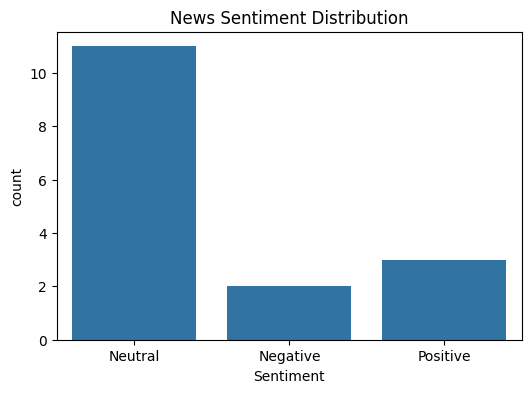

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sentiment", data=df)

plt.title("News Sentiment Distribution")
plt.show()

In [12]:
top_sources = df["Source"].value_counts().head(10)

print(top_sources)

Source
BBC News               4
Yahoo Entertainment    3
Android Central        2
The Verge              2
MacRumors              2
Slashdot.org           1
Popular Science        1
Business Insider       1
Name: count, dtype: int64


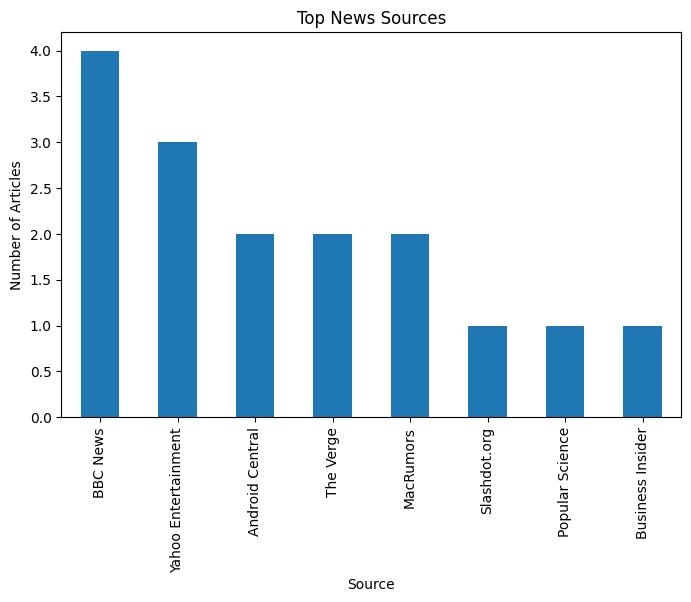

In [13]:
plt.figure(figsize=(8,5))
top_sources.plot(kind="bar")

plt.title("Top News Sources")
plt.xlabel("Source")
plt.ylabel("Number of Articles")

plt.show()

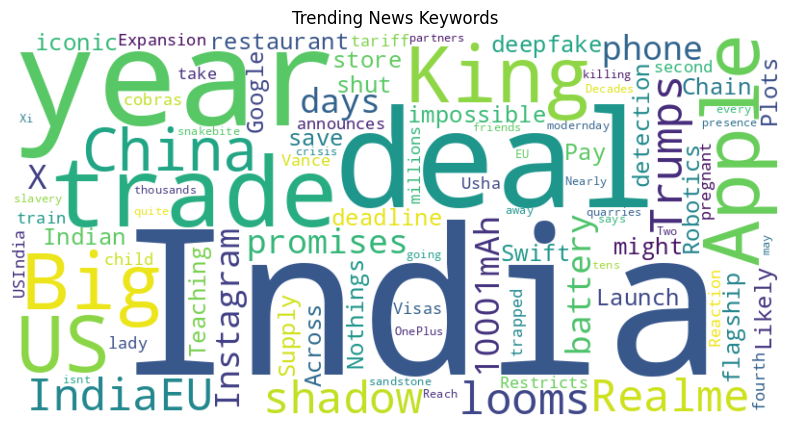

In [14]:
text = " ".join(df["Title"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Trending News Keywords")
plt.show()

In [15]:
df.to_csv("news_analysis_output.csv", index=False)

print("Analysis file saved successfully!")

Analysis file saved successfully!
